In [6]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import json

from src.networks.DecoderPINN import PINN, compute_residual
from src.physics.physics import get_M_non_const
from src.visualization.pdeplots import get_eval_grid, plot_residual_map, plot_fixed_scar_comparison
from src.utils.metrics import compute_and_print_metrics
from src.hyperparameters import hypers_fixedscar as h
from src.visualization.pdeplots import N_GRID

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

U_SCALE = float(np.load('data/models/u_scale_var.npy')[0])

model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1,2)))

with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']

pretrained_weights = f'data/models/weights/{pipeline_id}_decoder_lbfgs.weights.h5'
model.load_weights(pretrained_weights)
print(f"Model loaded: {pipeline_id} ")

Model loaded: 20260910_154245 


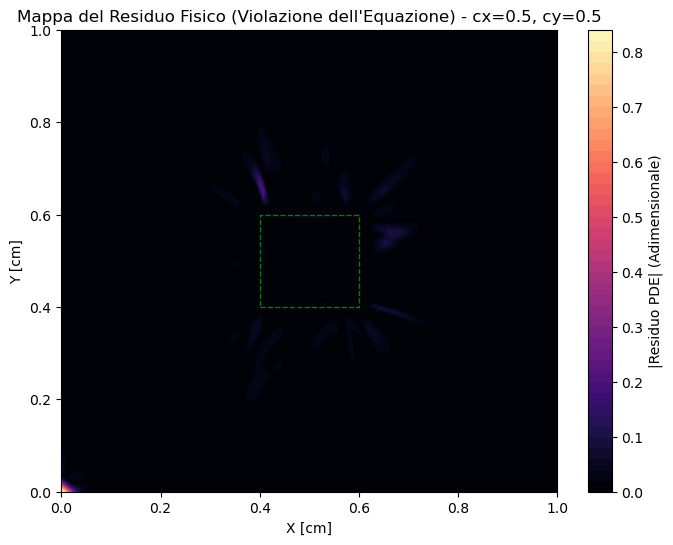

In [7]:
N_res = 200
X_res, Y_res, X_res_tensor = get_eval_grid(N_res)
pde_res = compute_residual(model, X_res_tensor, get_M_non_const)
Residual_Grid = np.abs(pde_res.numpy()).reshape(N_res, N_res)

plot_residual_map(X_res, Y_res, Residual_Grid)

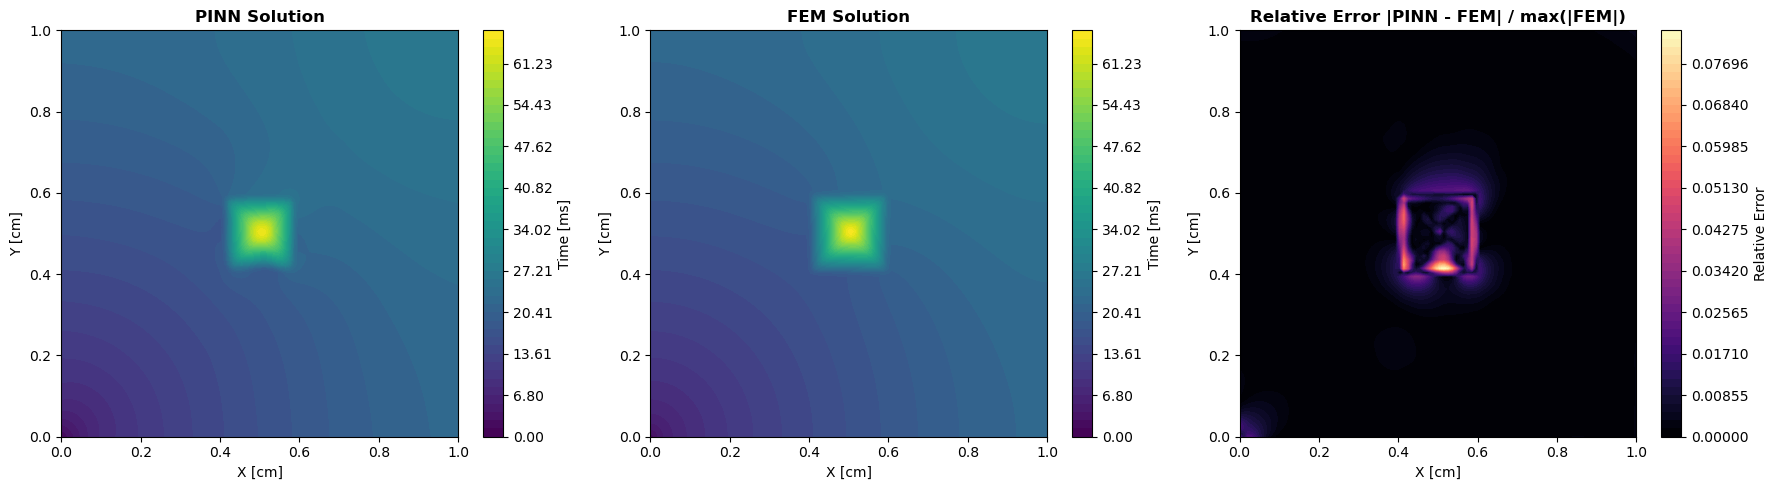

In [8]:
N_fem = N_GRID
X_fem, Y_fem, X_fem_tensor = get_eval_grid(N_fem)

u_pinn = model(X_fem_tensor).numpy().flatten() * U_SCALE
u_fem = np.load('data/fem/fem_grid_non_const.npy').flatten()

rel_err = np.abs(u_pinn - u_fem) / np.max((np.abs(u_fem)))

U_pinn2D = u_pinn.reshape(N_fem, N_fem) * 1000.0
U_fem2D = u_fem.reshape(N_fem, N_fem) * 1000.0
Rel_err2D = rel_err.reshape(N_fem, N_fem)

plot_fixed_scar_comparison(X_fem, Y_fem, U_pinn2D, U_fem2D, Rel_err2D)

In [9]:
# final evaluation on test data
test_mse, test_mae = compute_and_print_metrics(u_fem, u_pinn, U_SCALE)

Test MSE (Adimensionale) : 3.290181e-05
Test MAE (Fisico)        : 0.1140 ms
